# Pandas Data Visualization: A Comprehensive Guide

This notebook is a comprehensive guide to data visualization using the built-in `.plot()` method in Pandas. This method is a convenient wrapper around the `matplotlib` library, allowing you to create insightful plots quickly and easily directly from your DataFrame.

This guide is divided into three parts:
* **Part 1: Introduction & Chart Quick Reference:** A high-level overview and a quick reference table of common charts, their purpose, and syntax.
* **Part 2: Detailed Chart Guide & Key Parameters:** A deeper dive into each chart type with sample data and explanations of key parameters.
* **Part 3: Practical EDA with the "Tips" Dataset:** Applying these visualization techniques to perform Exploratory Data Analysis (EDA) on a real-world dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # We'll use this to load the 'tips' dataset

# Set plots to display inline in the notebook
%matplotlib inline

# Set a default figure size for better readability
plt.rcParams['figure.figsize'] = (10, 6)

# Part 1: Introduction & Chart Quick Reference

Pandas' plotting capabilities are accessed via the `.plot()` attribute on a Series or DataFrame. The basic syntax is `df.plot(kind='chart_type', ...)`. If you don't specify `kind`, it defaults to a line chart.

### Quick Reference Table

| Chart Type | EDA Purpose | Basic `pandas.plot()` Syntax |
| :--- | :--- | :--- |
| **Line** | Show trends over a continuous interval (e.g., time). | `df.plot(kind='line')` or `df.plot()` |
| **Bar** | Compare numerical values across categories. | `df.plot(kind='bar')` |
| **Barh** | Compare categories (good for long category names). | `df.plot(kind='barh')` |
| **Stacked Bar** | Show composition/parts of a whole for each category. | `df.plot(kind='bar', stacked=True)` |
| **Pie** | Show proportions of a whole (use with < 6 categories). | `df.plot(kind='pie', y='column_name')` |
| **Area** | Show volume/magnitude trends over time. | `df.plot(kind='area')` |
| **Stacked Area** | Show composition of volume trends over time. | `df.plot(kind='area', stacked=True)` |
| **Histogram** | Show the distribution (frequency) of a single numerical variable. | `df.plot(kind='hist', bins=20)` |
| **Box Plot** | Show distribution, quartiles, median, and outliers. | `df.plot(kind='box')` |
| **Scatter** | Show the relationship between two numerical variables. | `df.plot(kind='scatter', x='col1', y='col2')` |
| **Bubble** | Show the relationship between three numerical variables. | `df.plot(kind='scatter', x='col1', y='col2', s='col3')` |
| **Heatmap** | Show correlation matrix or 2D density. | *(Not a direct `.plot()` kind. Use `plt.imshow()` or `seaborn.heatmap()`)* |

# Part 2: Detailed Chart Guide & Key Parameters

In this section, we'll create sample data for each plot to demonstrate its use and key parameters.

## 2.1 Bar Charts (Vertical & Horizontal)

**Purpose:** Ideal for comparing numerical values across different, distinct categories.

**Key Parameters:**
* `kind='bar'` or `kind='barh'` (horizontal)
* `x`, `y`: Specify columns if not using the DataFrame index.
* `title='Chart Title'`: Sets the chart's title.
* `legend=False`: Hides the legend (often good for single-series bar charts).
* `color='blue'`: Sets a specific color.

### When to use Vertical (`bar`) vs. Horizontal (`barh`)?

* **Vertical (`kind='bar'`):** Use this when you have **few categories** (e.g., < 8) and their labels are **short** (e.g., 'Q1', 'North', 'Yes/No').
* **Horizontal (`kind='barh'`):** This is the **best choice** when you have **many categories** or your category labels are **long** (e.g., 'United States of America', 'Social Media Campaign'). It's much easier for the human eye to read labels horizontally.

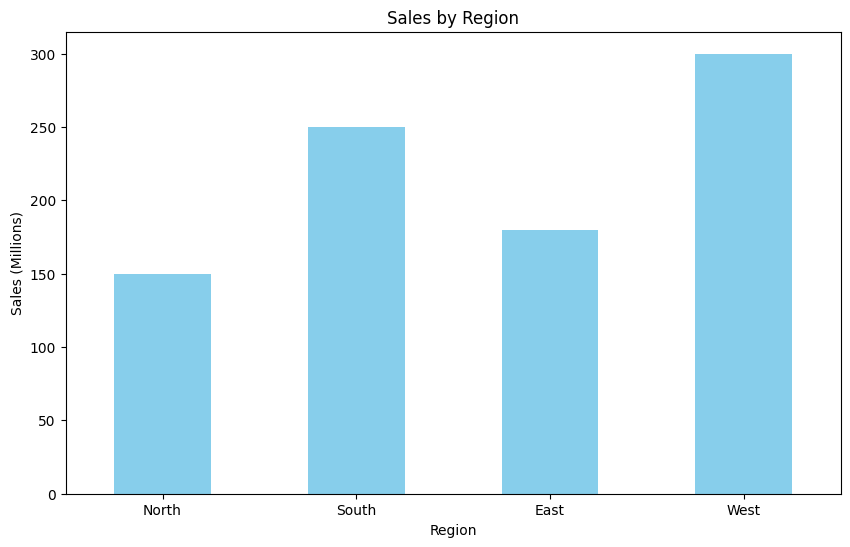

In [2]:
# Sample data: Sales by region
data_bar = {'Region': ['North', 'South', 'East', 'West'], 'Sales': [150, 250, 180, 300]}
df_bar = pd.DataFrame(data_bar).set_index('Region')

# Vertical Bar Chart
ax_bar = df_bar.plot(kind='bar', title='Sales by Region', legend=False, color='skyblue')
ax_bar.set_xlabel('Region')
ax_bar.set_ylabel('Sales (Millions)')
ax_bar.tick_params(axis='x', rotation=0) # Keep x-labels horizontal

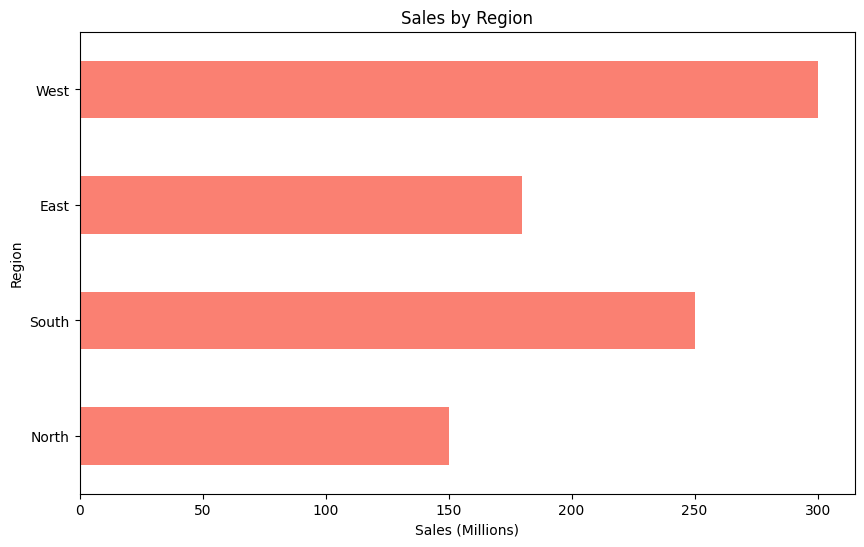

In [3]:
# Horizontal Bar Chart (good for long labels)
ax_barh = df_bar.plot(kind='barh', title='Sales by Region', legend=False, color='salmon')
ax_barh.set_xlabel('Sales (Millions)')
ax_barh.set_ylabel('Region');

## 2.2 Stacked Bar Chart

**Purpose:** Shows how a larger category is divided into smaller sub-categories and their contribution to the total.

**Key Parameters:**
* `kind='bar'` or `kind='barh'`
* `stacked=True`: This is the key parameter to stack the bars.

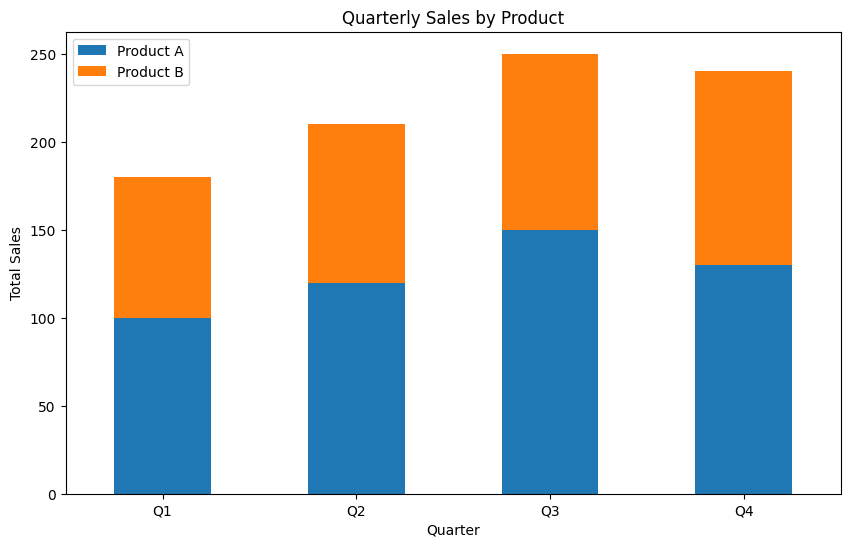

In [4]:
# Sample data: Sales by quarter for 2 products
data_stacked = {'Product A': [100, 120, 150, 130], 
                'Product B': [80, 90, 100, 110]}
df_stacked = pd.DataFrame(data_stacked, index=['Q1', 'Q2', 'Q3', 'Q4'])

ax_stacked = df_stacked.plot(kind='bar', stacked=True, title='Quarterly Sales by Product')
ax_stacked.set_xlabel('Quarter')
ax_stacked.set_ylabel('Total Sales')
ax_stacked.tick_params(axis='x', rotation=0);


## 2.3 Pie Chart

**Purpose:** Best for showing proportions or percentages of a whole. **Warning:** Use sparingly and only with a few categories (e.g., < 6), as it's hard to compare slice sizes.

**Key Parameters:**
* `kind='pie'`
* `y`: **Required**. The column whose values will be plotted.
* `autopct='%1.1f%%'`: (Optional) Displays percentage labels on each slice.
* `legend=False`: Often cleaner to remove the legend if using `autopct`.
* `labels=...`: Can specify labels, but it defaults to using the DataFrame index.

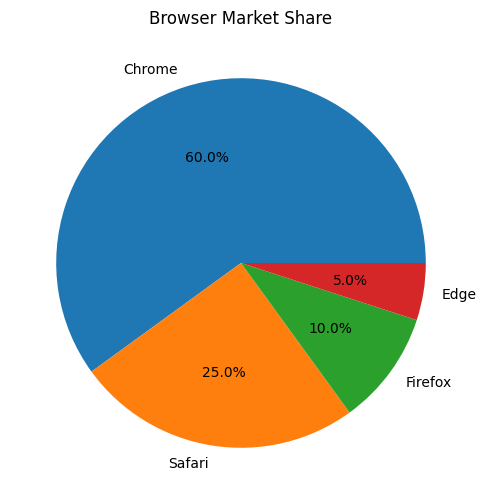

In [5]:
# Sample data: Browser market share
data_pie = {'Market Share': [60, 25, 10, 5]}
df_pie = pd.DataFrame(data_pie, index=['Chrome', 'Safari', 'Firefox', 'Edge'])

ax_pie = df_pie.plot(kind='pie', 
                     y='Market Share', 
                     title='Browser Market Share', 
                     autopct='%1.1f%%', 
                     legend=False)

ax_pie.set_ylabel(''); # Removes the 'Market Share' y-label


## 2.4 Line Chart

**Purpose:** Excellent for visualizing trends over a continuous interval, usually time (time-series data).

**Key Parameters:**
* `kind='line'` (this is the default plot type)
* `x`, `y`: Can be specified, but it defaults to using the index for `x` and all numeric columns for `y`.
* `marker='o'`: (Optional) Adds markers (like 'o', 'x', '+', 's') to data points.
* `grid=True`: (Optional) Displays a grid.

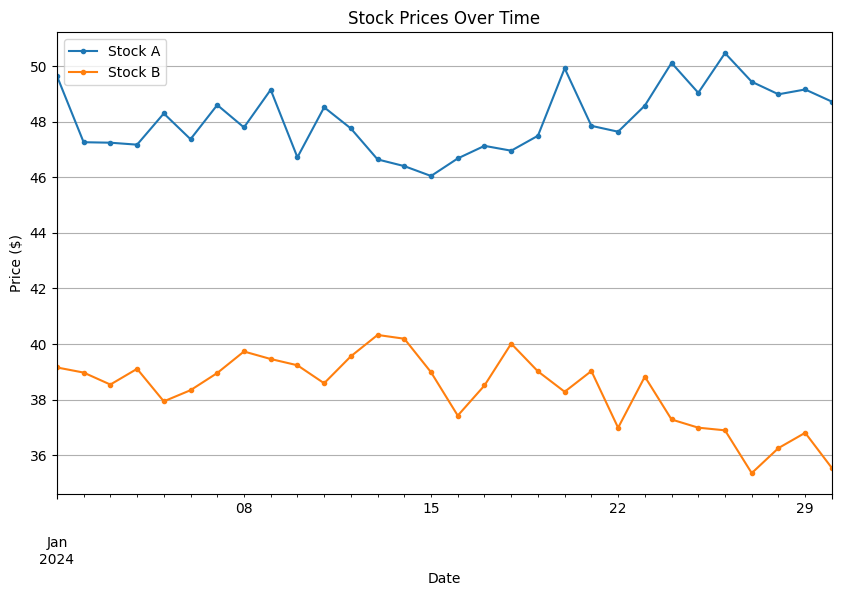

In [6]:
# Sample data: Stock prices over 30 days
data_line = {'Stock A': 50 + np.cumsum(np.random.randn(30)),
             'Stock B': 40 + np.cumsum(np.random.randn(30))}
df_line = pd.DataFrame(data_line, index=pd.date_range(start='2024-01-01', periods=30))

ax_line = df_line.plot(kind='line', 
                       title='Stock Prices Over Time', 
                       marker='.', 
                       grid=True)

ax_line.set_xlabel('Date')
ax_line.set_ylabel('Price ($)');


## 2.5 Area Chart

**Purpose:** Similar to line charts, but the area under the line is filled. Good for showing volume changes over time. By default, it creates a **Stacked Area Chart**.

**Key Parameters:**
* `kind='area'`
* `stacked=True`: (Default) Stacks areas on top of each other. Good for showing the composition of a total volume.
* `stacked=False`: Overlaps areas. If using this, set `alpha` for transparency.
* `alpha=0.5`: Sets transparency (0=transparent, 1=opaque).

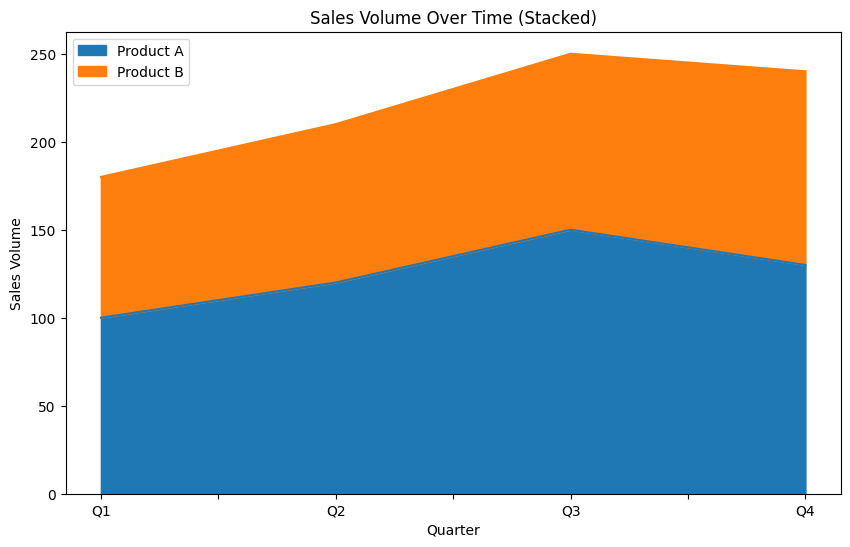

In [7]:
# Using the df_stacked data from the bar chart example

# Default (Stacked Area Chart)
ax_area_stacked = df_stacked.plot(kind='area', stacked=True, title='Sales Volume Over Time (Stacked)')
ax_area_stacked.set_xlabel('Quarter')
ax_area_stacked.set_ylabel('Sales Volume');

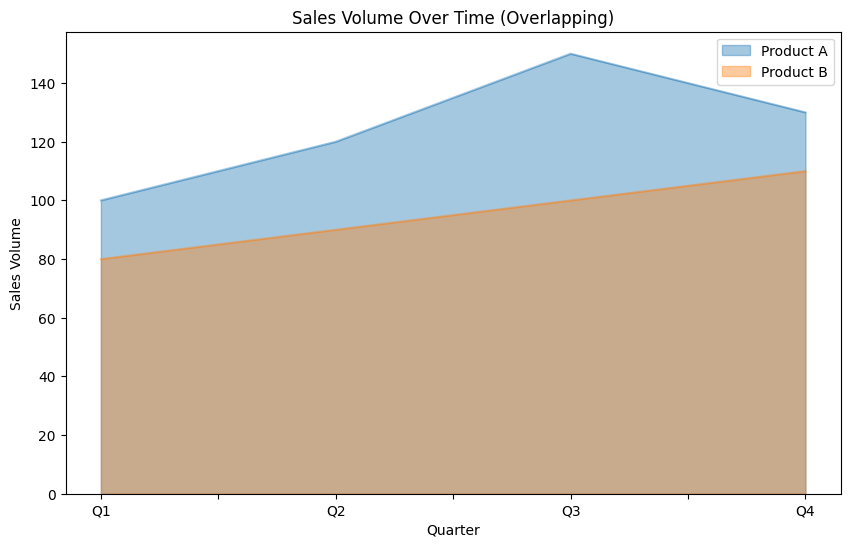

In [8]:

# Overlapping Area Chart
ax_area_overlap = df_stacked.plot(kind='area', stacked=False, alpha=0.4, title='Sales Volume Over Time (Overlapping)')
ax_area_overlap.set_xlabel('Quarter')
ax_area_overlap.set_ylabel('Sales Volume');

## 2.6 Scatter Plots & Bubble Charts

**Purpose:** Used to observe the relationship (correlation) between two numerical variables. A **Bubble Chart** is a scatter plot that adds a third numerical variable, represented by the *size* of the points.

**Key Parameters:**
* `kind='scatter'`
* `x`: (Required) The column for the x-axis.
* `y`: (Required) The column for the y-axis.
* `s`: (For Bubble charts) The column or array to determine the *size* of the points.
* `c`: (Optional) The column to determine the *color* of the points (a 4th dimension!).
* `alpha=0.5`: Transparency, useful when points overlap.

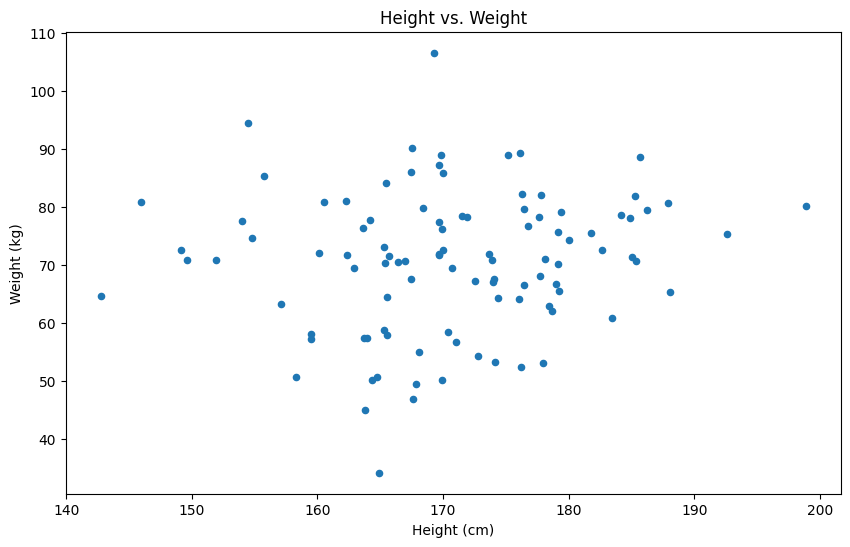

In [9]:
# Sample data: Height, Weight, and Age
N = 100
df_scatter = pd.DataFrame({
    'Height (cm)': np.random.normal(170, 10, N),
    'Weight (kg)': np.random.normal(70, 15, N),
    'Age': np.random.randint(18, 60, N)
})

# Simple Scatter Plot
df_scatter.plot(kind='scatter', x='Height (cm)', y='Weight (kg)', title='Height vs. Weight');

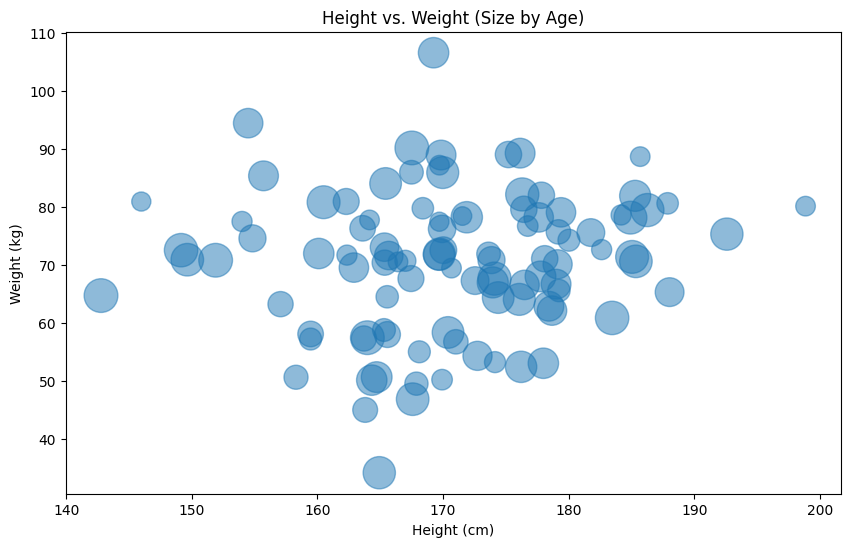

In [10]:

# Bubble Chart (size='Age')
# We multiply 'Age' by 10 to make the size difference more visible
df_scatter.plot(kind='scatter', 
                x='Height (cm)', 
                y='Weight (kg)', 
                s=df_scatter['Age']*10, 
                alpha=0.5, 
                title='Height vs. Weight (Size by Age)');

## 2.7 Histograms & Box Plots (Distribution Charts)

**Purpose:** Used to understand the *distribution* of a single numerical variable.
* **Histogram:** Shows frequency within specific ranges (bins).
* **Box Plot:** Shows quartiles, median, and outliers in a compact way. Great for comparing distributions across categories.

**Key Parameters (Histogram):**
* `kind='hist'`
* `y`: The column to plot (or plots all numeric columns).
* `bins=30`: (Important) Number of bins to divide the data into.

**Key Parameters (Box Plot):**
* `kind='box'`
* `by='category_column'`: (Optional) Groups the data and creates multiple box plots.

### When to use a Histogram vs. a Box Plot?

* **Histogram:** Use a histogram when you want to see the **shape** of the distribution. Is it normal (bell-shaped)? Skewed (left/right)? Bimodal (two peaks)? It's great for understanding the *frequency* of values.
* **Box Plot:** Use a box plot when you want a quick statistical summary: the **median** (50th percentile), the **interquartile range (IQR)** (the middle 50% of data), and especially **outliers**. It is *excellent* for comparing the distributions of a variable across multiple categories side-by-side.

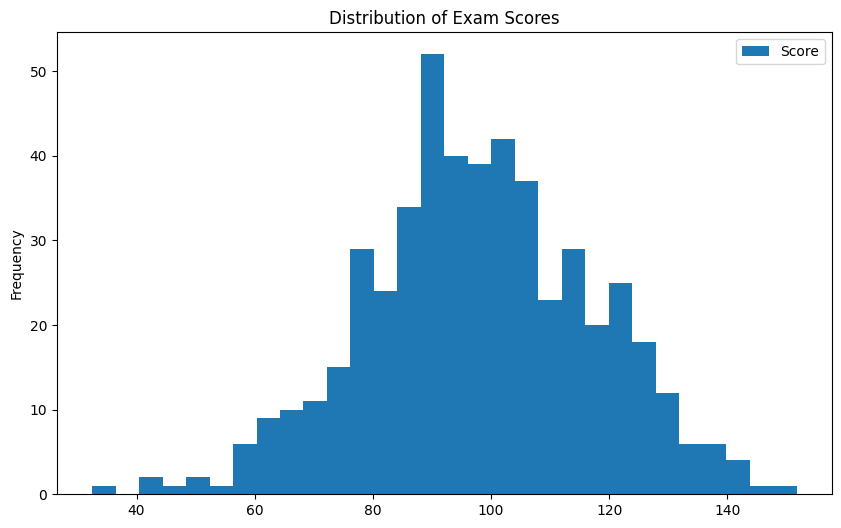

In [11]:
# Sample data: Exam scores
data_dist = np.random.normal(100, 20, 500)
df_dist = pd.DataFrame({'Score': data_dist})

# Histogram
df_dist.plot(kind='hist', y='Score', bins=30, title='Distribution of Exam Scores');

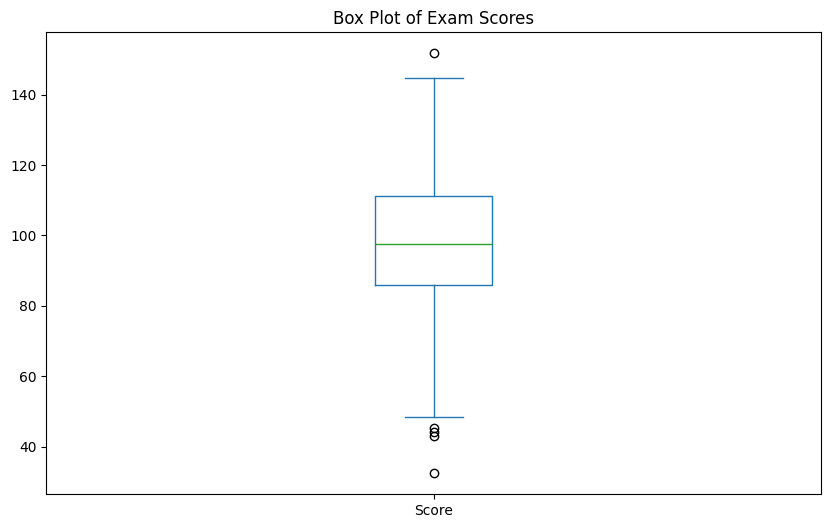

In [12]:

# Box Plot
df_dist.plot(kind='box', y='Score', title='Box Plot of Exam Scores');

--- 
## What is Exploratory Data Analysis (EDA)?

Before we dive into the practical example, let's define EDA.

**Exploratory Data Analysis (EDA)** is the process of investigating, summarizing, and visualizing a dataset to understand its main characteristics. The goal is not to create a final, formal model, but to "get to know" your data. 

Through EDA, we:
* Identify patterns and relationships (like the correlation we'll find between `tip` and `total_bill`).
* Spot anomalies, outliers, or missing data.
* Test initial hypotheses (e.g., "Do people tip more on weekends?").
* Determine which variables are important.

Visualization is the most powerful tool for effective EDA, and `pandas.plot()` is one of the fastest ways to do it.
--- 

# Part 3: Practical EDA with the "Tips" Dataset

Now, let's apply these charts to a real dataset. We will use the 'tips' dataset from the Seaborn library, which contains data about restaurant tips.

In [13]:
# Load the dataset
tips = sns.load_dataset('tips')

# Inspect the data
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [14]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


--- 
### Q1: What is the distribution of the `total_bill`?

**Chart:** Histogram (to see the frequency distribution of a single numerical variable).

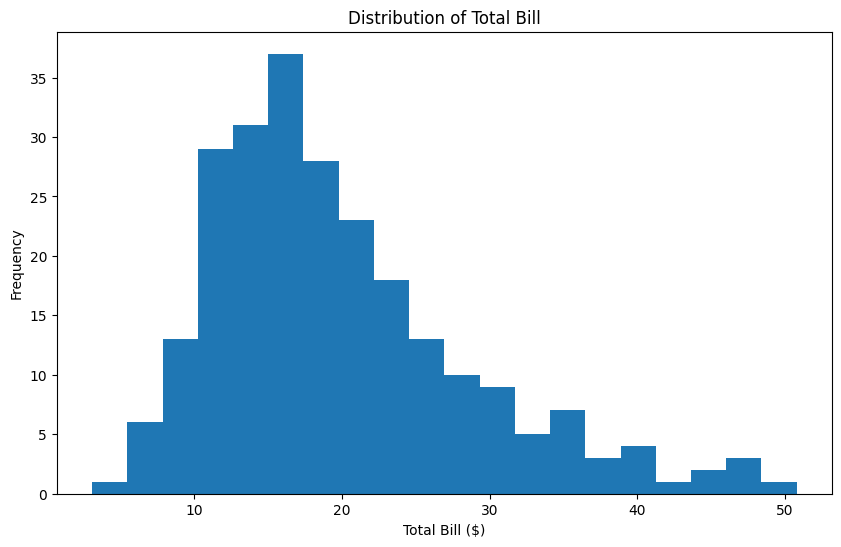

In [15]:
tips['total_bill'].plot(kind='hist', bins=20, title='Distribution of Total Bill')
plt.xlabel('Total Bill ($)');


**Interpretation:** The `total_bill` is right-skewed. Most bills are between $10 and $20, with a few large bills going up to $50.

--- 
### Q2: Is there a relationship between the `total_bill` and the `tip` amount?

**Chart:** Scatter Plot (to see the relationship between two numerical variables).

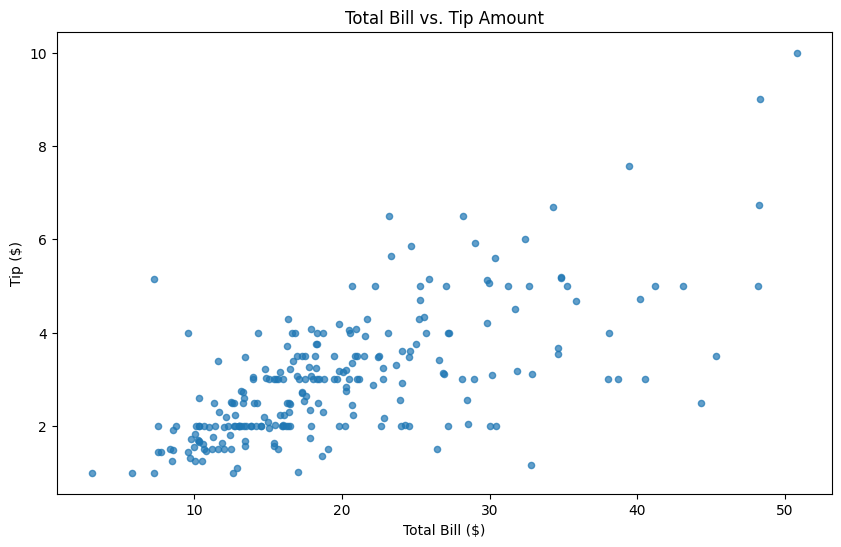

In [16]:
tips.plot(kind='scatter', x='total_bill', y='tip', title='Total Bill vs. Tip Amount', alpha=0.7)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)');

**Interpretation:** There is a clear positive correlation. As the `total_bill` increases, the `tip` amount generally increases as well.

--- 
### Q3: How does party `size` affect the relationship between `total_bill` and `tip`?

**Chart:** Bubble Chart (two numerical variables + a third numerical variable for size).

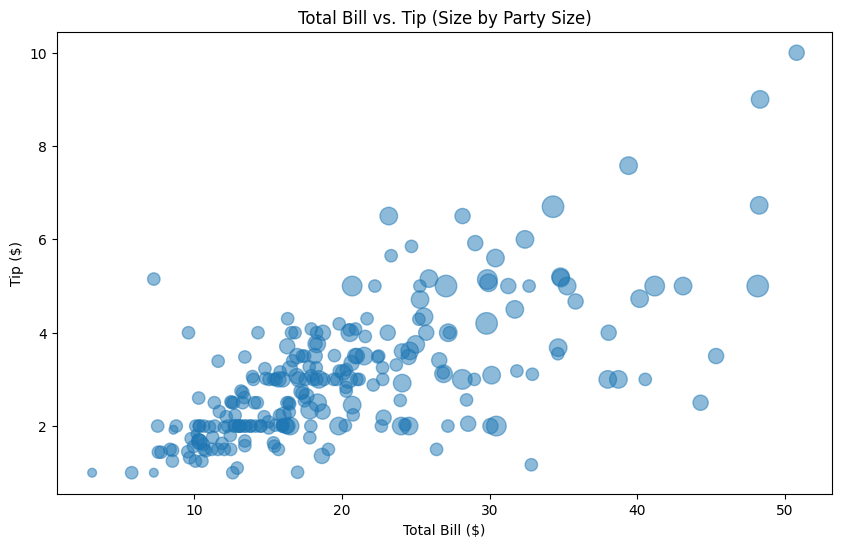

In [17]:
tips.plot(kind='scatter', 
          x='total_bill', 
          y='tip', 
          s=tips['size']*40,  # Scale size for better visibility
          alpha=0.5, 
          title='Total Bill vs. Tip (Size by Party Size)')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)');

**Interpretation:** We can see that larger party sizes (bigger bubbles) correspond to higher total bills and higher tips, reinforcing the correlation and showing the influence of party size.

--- 
### Q4: What is the average total bill by day of the week?

**Chart:** Bar Chart (comparing a numerical value across categories).

*Note: We must first aggregate the data using `groupby()`.*

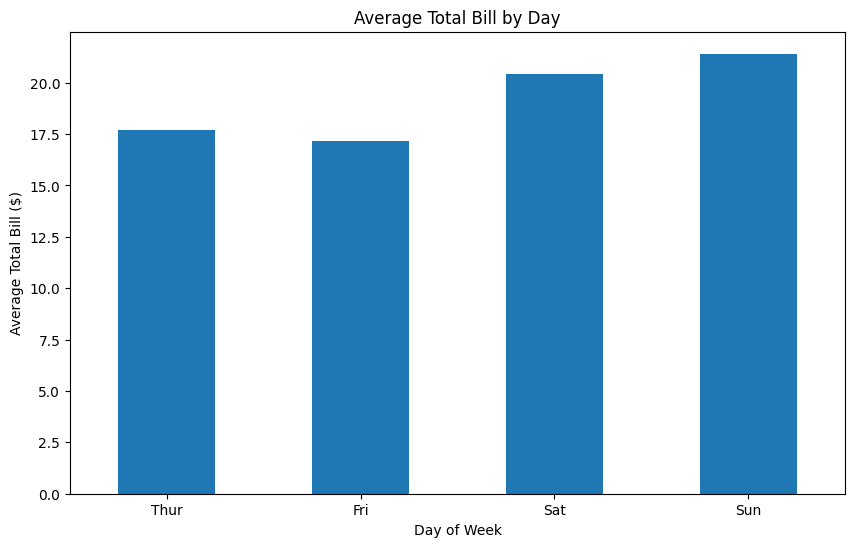

In [18]:
# We must first aggregate the data
avg_bill_by_day = tips.groupby('day', observed=True)['total_bill'].mean()

avg_bill_by_day.plot(kind='bar', title='Average Total Bill by Day')
plt.xlabel('Day of Week')
plt.ylabel('Average Total Bill ($)')
plt.xticks(rotation=0);


**Interpretation:** Customers spend the most on average on Saturday and Sunday (the weekend).

--- 
### Q5: What is the composition of total sales by day, broken down by `time` (Lunch/Dinner)?

**Chart:** Stacked Bar Chart (comparing a total across categories, with sub-category composition).

*Note: We need to `pivot_table()` the data to get the right shape.*

C:\Users\Admin\AppData\Local\Temp\ipykernel_9676\3915764203.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sales_by_day_time = tips.pivot_table(index='day',


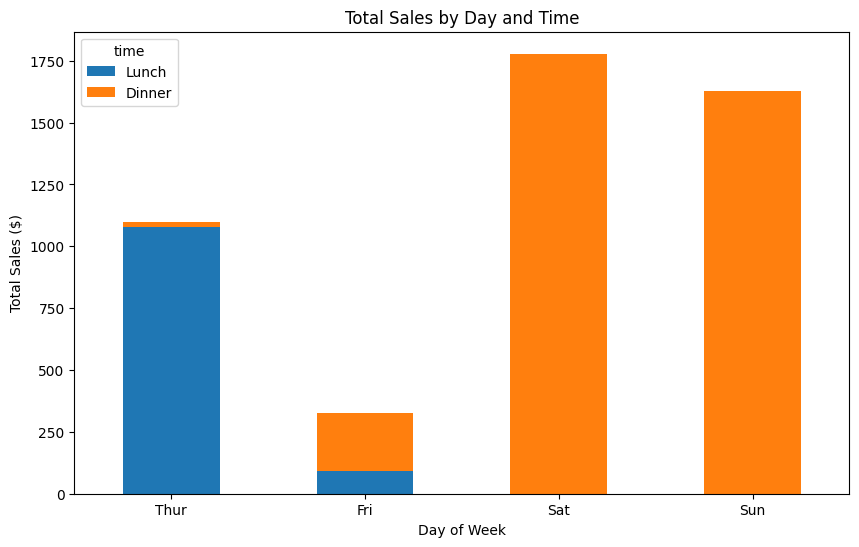

In [19]:
# We need to pivot the data to get 'day' as index, 'time' as columns
sales_by_day_time = tips.pivot_table(index='day', 
                                     columns='time', 
                                     values='total_bill', 
                                     aggfunc='sum')

sales_by_day_time.plot(kind='bar', stacked=True, title='Total Sales by Day and Time')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0);


**Interpretation:** Lunch sales are significant on Thursday and Friday. Dinner sales completely dominate the weekend (Saturday/Sunday). This dataset seems to have almost no Dinner data for Thursday.

--- 
### Q6: What is the distribution of `tip` amounts for each day?

**Chart:** Box Plot (ideal for comparing distributions across multiple categories).

*Note: We can use the `by=` parameter to group.*

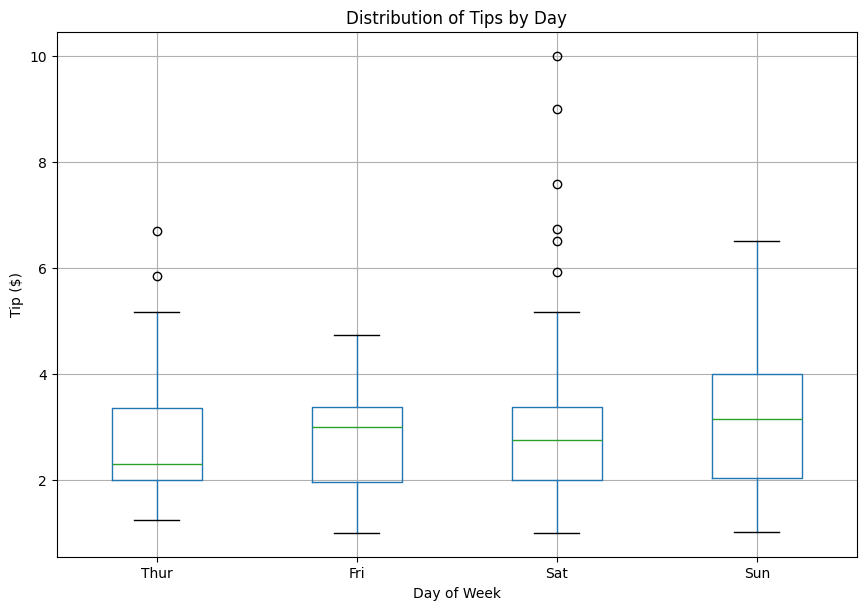

In [20]:
# The .plot(kind='box', by=...) can sometimes have issues with categorical data.
# A more stable pandas method is to use .boxplot() directly.
tips.boxplot(column='tip', by='day', figsize=(10, 7))

# Clean up the default titles
plt.title('Distribution of Tips by Day')
plt.suptitle('') # Remove the default "Box plot grouped by day"
plt.xlabel('Day of Week')
plt.ylabel('Tip ($)');


**Interpretation:** The median tip (the orange line) is fairly consistent across all four days (around $2.50-$3.00). Saturday has the widest distribution and the most high-value outliers (the circles). All days have some outliers.

# Conclusion

This notebook has provided a comprehensive guide to performing quick and effective data visualizations directly from Pandas. By understanding the purpose of each chart and its key parameters, you can rapidly move from data to insights. For more advanced customization, you can always use `matplotlib`'s functions directly on the `ax` (Axes) object returned by the `.plot()` method.

# Summary of Key Insights

Our exploratory data analysis on the 'tips' dataset revealed several key insights about the restaurant's customers:

* **Bill & Tip Correlation:** There is a strong positive relationship between the `total_bill` and the `tip` amount. As the bill increases, the tip tends to increase as well.
* **Bill Distribution:** Most bills are concentrated in the $10-$20 range, with the distribution being right-skewed (a few very high bills).
* **Weekend Activity:** The restaurant is busiest on weekends. Customers spend more on average on Saturdays and Sundays.
* **Meal Times:** Lunch is a significant part of business on Thursdays and Fridays, but dinner sales completely dominate the weekend.
* **Tipping Behavior:** While the median tip is fairly consistent across all days (around $2.50-$3.00), Saturday sees the widest range of tips and the most high-value outliers.
* **Party Size:** Party `size` is a key driver, correlating with both higher total bills and larger tips.